In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data911 = pd.read_csv('911.csv')

In [4]:
data911.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 663522 entries, 0 to 663521
Data columns (total 9 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   lat        663522 non-null  float64
 1   lng        663522 non-null  float64
 2   desc       663522 non-null  object 
 3   zip        583323 non-null  float64
 4   title      663522 non-null  object 
 5   timeStamp  663522 non-null  object 
 6   twp        663229 non-null  object 
 7   addr       663522 non-null  object 
 8   e          663522 non-null  int64  
dtypes: float64(3), int64(1), object(5)
memory usage: 45.6+ MB


In [6]:
data911.head(4)

,lat,lng,desc,zip,title,timeStamp,twp,addr,e
0,40.297876,-75.581294,REINDEER CT & DEAD END; NEW HANOVER; Station ...,19525.0,EMS: BACK PAINS/INJURY,2015-12-10 17:10:52,NEW HANOVER,REINDEER CT & DEAD END,1
1,40.258061,-75.264680,BRIAR PATH & WHITEMARSH LN; HATFIELD TOWNSHIP...,19446.0,EMS: DIABETIC EMERGENCY,2015-12-10 17:29:21,HATFIELD TOWNSHIP,BRIAR PATH & WHITEMARSH LN,1
2,40.121182,-75.351975,HAWS AVE; NORRISTOWN; 2015-12-10 @ 14:39:21-St...,19401.0,Fire: GAS-ODOR/LEAK,2015-12-10 14:39:21,NORRISTOWN,HAWS AVE,1
3,40.116153,-75.343513,AIRY ST & SWEDE ST; NORRISTOWN; Station 308A;...,19401.0,EMS: CARDIAC EMERGENCY,2015-12-10 16:47:36,NORRISTOWN,AIRY ST & SWEDE ST,1


In [7]:
data911['zip'].value_counts().head(4)

zip
19401.0    45606
19464.0    43910
19403.0    34888
19446.0    32270
Name: count, dtype: int64

In [10]:
x = data911['title'].iloc[0]

In [ ]:
x.split(':')[0]     

'EMS'

In [12]:
data911['Reason'] = data911['title'].apply(lambda title: title.split(':')[0])

In [14]:
data911['Reason'].value_counts()

Reason
EMS        332692
Traffic    230208
Fire       100622
Name: count, dtype: int64

<Axes: xlabel='Reason', ylabel='count'>

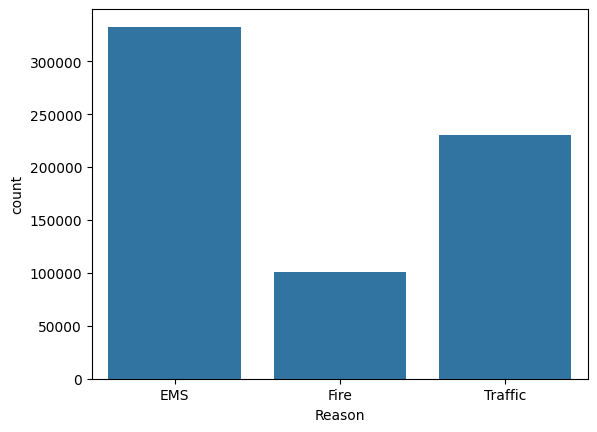

In [17]:
sns.countplot(x='Reason', data=data911)

In [18]:
data911['timeStamp'] = pd.to_datetime(data911['timeStamp'])

In [20]:
time = data911['timeStamp'][0]
time.hour

17

In [21]:
data911['Hour'] = data911['timeStamp'].apply(lambda time: time.hour)
data911['Month'] = data911['timeStamp'].apply(lambda time: time.month)
data911['Day'] = data911['timeStamp'].apply(lambda time: time.day)
data911['DayOfWeek'] = data911['timeStamp'].apply(lambda time: time.dayofweek)
data911['Year'] = data911['timeStamp'].apply(lambda time: time.year)

In [22]:
data911.head(4)


,lat,lng,desc,zip,title,timeStamp,twp,addr,e,Reason,Hour,Month,Day,DayOfWeek,Year
0,40.297876,-75.581294,REINDEER CT & DEAD END; NEW HANOVER; Station ...,19525.0,EMS: BACK PAINS/INJURY,2015-12-10 17:10:52,NEW HANOVER,REINDEER CT & DEAD END,1,EMS,17,12,10,3,2015
1,40.258061,-75.264680,BRIAR PATH & WHITEMARSH LN; HATFIELD TOWNSHIP...,19446.0,EMS: DIABETIC EMERGENCY,2015-12-10 17:29:21,HATFIELD TOWNSHIP,BRIAR PATH & WHITEMARSH LN,1,EMS,17,12,10,3,2015
2,40.121182,-75.351975,HAWS AVE; NORRISTOWN; 2015-12-10 @ 14:39:21-St...,19401.0,Fire: GAS-ODOR/LEAK,2015-12-10 14:39:21,NORRISTOWN,HAWS AVE,1,Fire,14,12,10,3,2015
3,40.116153,-75.343513,AIRY ST & SWEDE ST; NORRISTOWN; Station 308A;...,19401.0,EMS: CARDIAC EMERGENCY,2015-12-10 16:47:36,NORRISTOWN,AIRY ST & SWEDE ST,1,EMS,16,12,10,3,2015


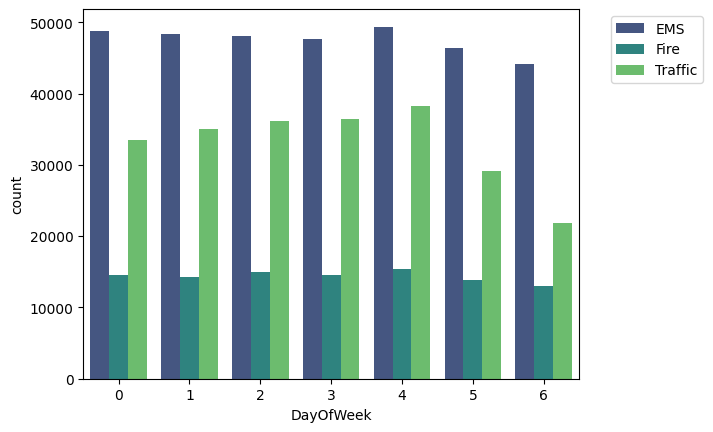

In [25]:
sns.countplot(x='DayOfWeek', data=data911, hue='Reason', palette='viridis')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

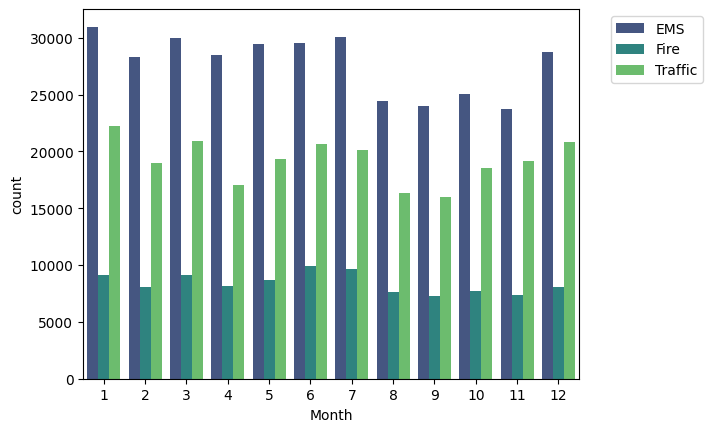

In [26]:
sns.countplot(x='Month', data=data911, hue='Reason', palette='viridis')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

In [27]:
byMonth = data911.groupby('Month').count()
byMonth.head(4)

,lat,lng,desc,zip,title,timeStamp,twp,addr,e,Reason,Hour,Day,DayOfWeek,Year
Month,,,,,,,,,,,,,,
1,62336,62336,62336,55294,62336,62336,62312,62336,62336,62336,62336,62336,62336,62336
2,55427,55427,55427,48922,55427,55427,55405,55427,55427,55427,55427,55427,55427,55427
3,60027,60027,60027,53252,60027,60027,60001,60027,60027,60027,60027,60027,60027,60027
4,53671,53671,53671,47349,53671,53671,53655,53671,53671,53671,53671,53671,53671,53671


<Axes: xlabel='Month'>

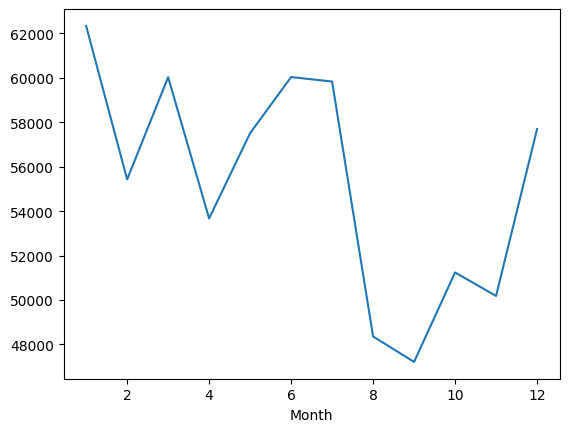

In [28]:
byMonth['lat'].plot()

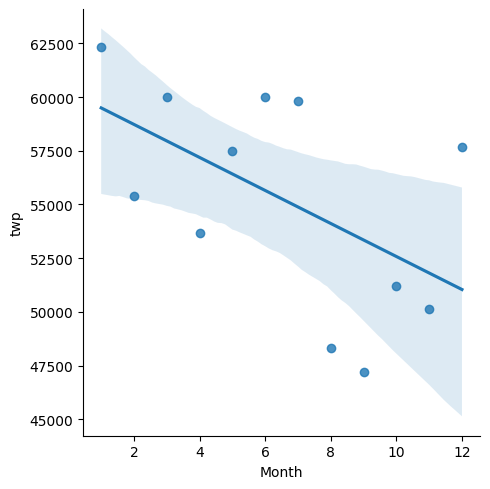

In [34]:
sns.lmplot(x='Month', y='twp', data=byMonth.reset_index(), palette='viridis')
